

---
## How to Run This Notebook
1. Place `template.jpg` and `shelf.jpg` in the same folder as this notebook.
2. Run all cells sequentially from top to bottom.
3. The product location will be displayed for both methods.



In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [18]:
# Load images
template_img = Image.open("template.jpg").convert("RGB")
shelf_img = Image.open("shelf.jpg").convert("RGB")

template = np.array(template_img).astype(np.float32)
shelf = np.array(shelf_img).astype(np.float32)

print("Template shape:", template.shape)
print("Shelf shape:", shelf.shape)

Template shape: (56, 39, 3)
Shelf shape: (400, 1000, 3)


In [19]:
template = template - np.mean(template)

In [20]:
def correlation(image, template):
    H, W, C = image.shape
    h, w, _ = template.shape
    
    output = np.zeros((H - h + 1, W - w + 1))
    
    for i in range(H - h + 1):
        for j in range(W - w + 1):
            patch = image[i:i+h, j:j+w, :]
            patch = patch - np.mean(patch)
            output[i, j] = np.sum(patch * template)
            
    return output

In [21]:
corr_map = correlation(shelf, template)

# Find maximum location
y_corr, x_corr = np.unravel_index(np.argmax(corr_map), corr_map.shape)

print("Correlation Match Location:", (x_corr, y_corr))

Correlation Match Location: (np.int64(41), np.int64(8))


In [22]:
flipped_template = np.flip(template, axis=(0,1))

In [23]:
def convolution(image, template):
    H, W, C = image.shape
    h, w, _ = template.shape
    
    output = np.zeros((H - h + 1, W - w + 1))
    
    for i in range(H - h + 1):
        for j in range(W - w + 1):
            patch = image[i:i+h, j:j+w, :]
            patch = patch - np.mean(patch)
            output[i, j] = np.sum(patch * template)
            
    return output

In [24]:
conv_map = convolution(shelf, flipped_template)

y_conv, x_conv = np.unravel_index(np.argmax(conv_map), conv_map.shape)

print("Convolution Match Location:", (x_conv, y_conv))

Convolution Match Location: (np.int64(431), np.int64(170))


In [ ]:
def draw_rectangle(image, x, y, w, h, thickness=6):
    img_copy = image.copy()

    H, W, _ = img_copy.shape

    
    x2 = min(x + w, W-1)
    y2 = min(y + h, H-1)

    
    for t in range(thickness):
        # Top border
        img_copy[y+t, x:x2] = [0, 0, 0]

        # Bottom border
        img_copy[y2-t, x:x2] = [0, 0, 0]

        # Left border
        img_copy[y:y2, x+t] = [0, 0, 0]

        # Right border
        img_copy[y:y2, x2-t] = [0, 0, 0]

    return img_copy

(np.float64(-0.5), np.float64(999.5), np.float64(399.5), np.float64(-0.5))

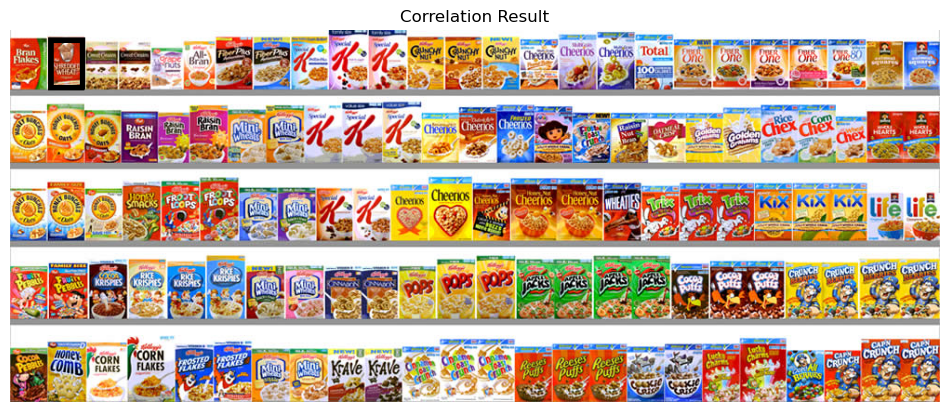

In [29]:
h, w, _ = template.shape

corr_result_img = draw_rectangle(shelf.astype(np.uint8), x_corr, y_corr, w, h)

plt.figure(figsize=(12,8))
plt.imshow(corr_result_img)
plt.title("Correlation Result")
plt.axis("off")

(np.float64(-0.5), np.float64(999.5), np.float64(399.5), np.float64(-0.5))

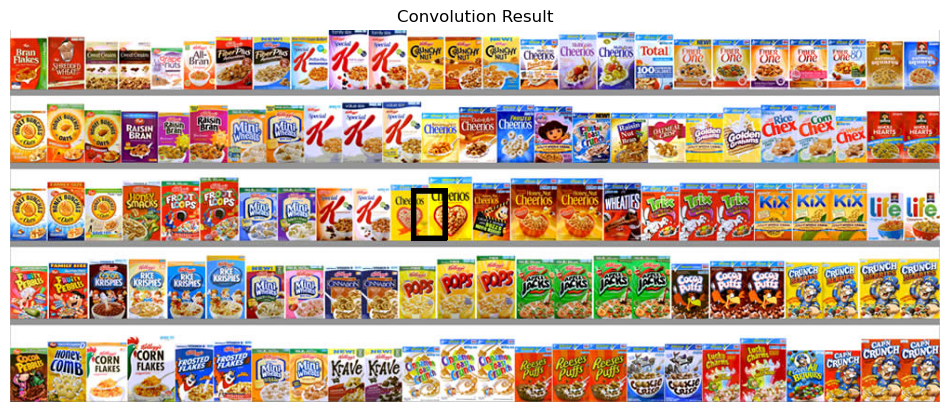

In [30]:
conv_result_img = draw_rectangle(shelf.astype(np.uint8), x_conv, y_conv, w, h)

plt.figure(figsize=(12,8))
plt.imshow(conv_result_img)
plt.title("Convolution Result")
plt.axis("off")

1) Which method more accurately locates the product and why?

Correlation locates the product more accurately because it compares the template without flipping it, preserving its original orientation. Convolution flips the template, which alters spatial structure and reduces matching accuracy when the object is not symmetric.


2) Which method is more efficient in terms of computation and implementation?

Both methods have the same computational complexity since they slide the template over the image and perform element-wise multiplications. However, correlation is slightly simpler to implement because it does not require flipping the template.


3) Why is one method better for template matching in this scenario?

Correlation is better because template matching is a similarity measurement problem, and correlation directly measures similarity without modifying the template. Since the product image is not symmetric, preserving orientation is essential for accurate detection.